# Import

### lib

In [88]:
import sys
import os
import datetime

import pandas as pd
import numpy as np
# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
from mlflow.tracking import MlflowClient
# viz
import matplotlib.pyplot as plt
# statistics
from scipy.stats import shapiro

In [89]:
sys.path.append("../../")


from ML.metric.regression import root_mean_squared_log_error, root_mean_squared_log_error_lgbm

### env & settings

In [90]:
DATA_DIR = "/workspace/Storage/kaggle/Data/insurance"
PATH_TRAIN = os.path.join(DATA_DIR, "raw", "train.csv")
PATH_TEST = os.path.join(DATA_DIR, "raw", "test.csv")

In [91]:
# 출력할 컬럼 수를 충분히 늘리기
pd.set_option('display.max_columns', None)

### Data

In [92]:
train = pd.read_csv(PATH_TRAIN)
X_submit = pd.read_csv(PATH_TEST)

In [93]:
train.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


# 1. preprocess

In [94]:
def preprocess(df):
    random_state = 42
    ref = "2024-08-16"
    # ordinal 인코딩
    ordinal_dict = {
        "Education Level" : {
            "High School": 1,
            "Bachelor's" : 2,
            "Master's" : 3,
            "PhD" : 4,
        },
        "Policy Type": {
            "Basic":1,
            "Comprehensive":2,
            "Premium":3
        },
        "Customer Feedback":{
            "Poor":1,
            "Average":2,
            "Good":3
        },
        "Exercise Frequency":{
            'Rarely':1,
            'Monthly':2,
            'Weekly':3,
            'Daily':4
        }
    }
    df[list(ordinal_dict.keys())] = df[ordinal_dict.keys()].apply(lambda col: col.map(lambda x: ordinal_dict[col.name][x] if not pd.isna(x) else x))
    # datetime 인코딩
    ref = datetime.datetime.strptime(ref, "%Y-%m-%d")
    df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date']).map(lambda x: (ref-x).total_seconds())
    # 결측처리
    for col in ['Health Score', 'Policy Start Date']:
        df[col] = df[col].fillna(df[col].mean())
    for col in ['Age', 'Annual Income','Vehicle Age','Credit Score','Insurance Duration','Customer Feedback','Exercise Frequency']:
        df[col] = df[col].fillna(df[col].median())
    for col in ['Education Level', 'Location', 'Policy Type', 'Smoking Status', 'Property Type']:
        df[col] = df[col].fillna(df[col].mode())
    for col in ['Previous Claims']:
        df[col] = df[col].fillna(0)
    for col in ['Gender', 'Marital Status', 'Number of Dependents', 'Occupation']:
        missing_indices = df[df[col].isna()].index
        
        # 기존 데이터에서 랜덤 추출
        n_missing = df[col].isna().sum()
        if not n_missing:
            continue
        
        imputes = df[col].dropna().sample(n=n_missing, random_state=random_state).tolist()
        
        # 결측치 주입
        df.loc[missing_indices, col] = imputes
        n_missing = df[col].isna().sum()
        
    # onehot 인코딩
    for col in ['Gender','Marital Status', 'Occupation', 'Location', 'Smoking Status', 'Property Type']:
        nominals = pd.get_dummies(train[col], prefix=col)
        df.drop(col, axis=1, inplace=True)
        df = pd.concat([df, nominals], axis=1)
    return df

In [95]:
train = preprocess(train)

## 1.3 split

In [96]:
train, val = train_test_split(train, test_size=0.4, random_state=421)
val, test = train_test_split(val, test_size=0.5, random_state=421)

In [97]:
train.shape, val.shape, test.shape

((720000, 31), (240000, 31), (240000, 31))

In [98]:
X_train, y_train = train[[x for x in train.columns if x != "Premium Amount"]], train["Premium Amount"]
X_val, y_val = val[[x for x in val.columns if x != "Premium Amount"]], val["Premium Amount"]
X_test, y_test = test[[x for x in test.columns if x != "Premium Amount"]], test["Premium Amount"]

# 2. Baseline

In [99]:
# 데이터셋 생성
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)


In [100]:

# 사용자 정의 콜백: epoch별 메트릭 로그 기록

class MlflowLoggingCallbackLGBM:
    def __init__(self, X_test, y_test, metric):
        self.X_test = X_test
        self.y_test = y_test
        self.metric = metric

    def __call__(self, env):
        # 매 step 마다 호출
        iteration = env.iteration + 1  # 0-indexed
        y_pred = env.model.predict(self.X_test, num_iteration=iteration)
        score = self.metric(self.y_test, y_pred)

        # MLflow에 기록
        # 검증 세트 점수도 기록
        for  valid_name, metric_name, valid_result, _ in env.evaluation_result_list:
            metrics = {
                "test" : score,
                "valid" : valid_result
            }
        mlflow.log_metrics(metrics, step=iteration, synchronous=False)

In [101]:

class MlflowLoggingCallbackLGBM:
    def __init__(self, X_test, y_test, metric):
        self.X_test = X_test
        self.y_test = y_test
        self.metric = metric

    def __call__(self, env):
        # 매 step 마다 호출
        iteration = env.iteration + 1  # 0-indexed
        y_pred = env.model.predict(self.X_test, num_iteration=iteration)
        score = self.metric(self.y_test, y_pred)

        # 손실(Loss) 값 가져오기
        
        metrics = {
            "test": score,
        }
        # MLflow에 기록
        for name, metric_name, value, _ in env.evaluation_result_list:
            metrics[name] = value
        mlflow.log_metrics(metrics, step=iteration, synchronous=False)

In [ ]:
# 모델 학습
# MLflow 실험 시작
mlflow.set_tracking_uri("http://175.214.62.133:50001/")
mlflow.set_experiment("lightgbm_rmsle_experiment")

with mlflow.start_run():
    
    # 하이퍼파라미터 설정
    params = {
        'objective': 'regression',  # 회귀 문제
        'metric': 'rmse',           # 평가 지표
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
    }

    callbacks = [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
        MlflowLoggingCallbackLGBM(X_test, y_test, root_mean_squared_error)
    ]

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data,valid_data],
        num_boost_round=1000,
        callbacks=callbacks,
        # feval = root_mean_squared_log_error_lgbm,
    )

    y_pred = model.predict(X_test, num_iteration=model.best_iteration)
    rmsle = root_mean_squared_log_error(y_test, y_pred)
    print("RMSLE:", rmsle)

    # MLflow에 파라미터 및 메트릭 기록
    mlflow.log_params(params)
    mlflow.log_metric("RMSLE", rmsle)
    
    # 모델 저장
    mlflow.lightgbm.log_model(model, "lightgbm_model")
    print("Model saved to MLflow")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1413
[LightGBM] [Info] Number of data points in the train set: 720000, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 1102.101694
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 842.538	valid_1's rmse: 844.128
[200]	training's rmse: 840.636	valid_1's rmse: 843.798
[300]	training's rmse: 838.949	valid_1's rmse: 843.641
Early stopping, best iteration is:
[296]	training's rmse: 839.011	valid_1's rmse: 843.637
RMSLE: 1.1396962155848709


2024/12/23 11:19:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model saved to MLflow
🏃 View run likeable-lynx-176 at: http://175.214.62.133:50001/#/experiments/286555346072408604/runs/12de31e3a56c4271bc918708797dc42b
🧪 View experiment at: http://175.214.62.133:50001/#/experiments/286555346072408604


# 3. Diagnistic Analysis

## 3.1 Descriptive Analysis

In [103]:
# MLflow 클라이언트 생성
client = MlflowClient()

# 모든 실험 확인
experiments = client.search_experiments()

for exp in experiments:
    print(f"Experiment ID: {exp.experiment_id}, Name: {exp.name}")

Experiment ID: 286555346072408604, Name: lightgbm_rmsle_experiment
Experiment ID: 0, Name: Default


In [104]:
# 특정 실험의 실행(run) 확인
experiment_id = "286555346072408604"  # Example experiment_id
runs = client.search_runs(experiment_id)
for run in runs:
    rund = run.to_dictionary()
    run_id = rund['info']['run_id']
    status = rund['info']['status']
    start_time = datetime.datetime.fromtimestamp(rund['info']['start_time']/1000)
    print(f"Run ID: {run_id}, Status: {status}, start time(UTC): {start_time}")

Run ID: 12de31e3a56c4271bc918708797dc42b, Status: FINISHED, start time(UTC): 2024-12-23 11:17:51.064000
Run ID: 04323b34dfaf4c8c83668f590b5daf58, Status: FINISHED, start time(UTC): 2024-12-23 11:01:12.803000
Run ID: dd1874b3909446f8bacc73d17ad07631, Status: FAILED, start time(UTC): 2024-12-23 10:58:32.575000
Run ID: 0a19514ae55a42fb85ec7f3cbf2f8ee2, Status: FINISHED, start time(UTC): 2024-12-23 10:47:20.846000
Run ID: ed6d36ed61654b46b2dfbc6191011344, Status: FINISHED, start time(UTC): 2024-12-23 10:34:54.267000
Run ID: 9f7b83554c5a43de835e950dc1e5bebf, Status: FINISHED, start time(UTC): 2024-12-23 10:30:22.296000
Run ID: 4e5d333a437b4a3296355b27348485be, Status: FINISHED, start time(UTC): 2024-12-23 10:21:09.608000
Run ID: 18848fc816a74e8b999806a4b4ec7e6d, Status: FAILED, start time(UTC): 2024-12-23 10:20:29.410000
Run ID: cb04de1014b5478c95c887f64b147c66, Status: FINISHED, start time(UTC): 2024-12-23 08:38:26.487000
Run ID: d7fc842bf5b24f3b93e1d1acdb3367e9, Status: FINISHED, start ti

In [118]:
# 특정 실행(run)의 상세 정보 가져오기
run_id = "04323b34dfaf4c8c83668f590b5daf58"
run = client.get_run(run_id)
run.data.metrics


{'test': 841.9230240980278,
 'training': 837.1281567799864,
 'RMSLE': 1.14045065451937,
 'valid_1': 842.9524377407042}

In [119]:
test = [x.value for x in client.get_metric_history(run_id, "test")]
valid = [x.value for x in client.get_metric_history(run_id, "valid_1")]
train = [x.value for x in client.get_metric_history(run_id, "training")]
steps = range(len(valid))

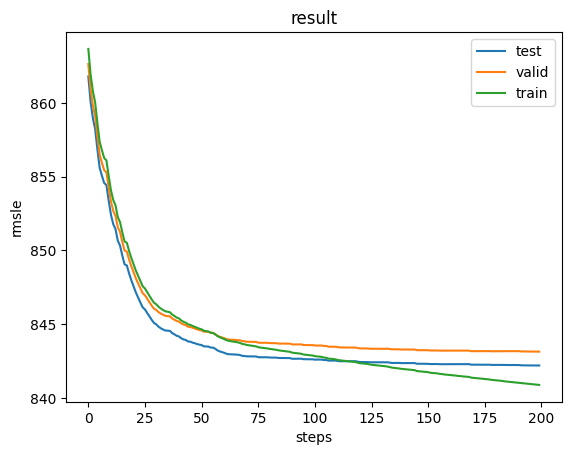

In [120]:
endpoint = 200
plt.plot(steps[:endpoint], test[:endpoint], label = 'test')
plt.plot(steps[:endpoint], valid[:endpoint], label = 'valid')
plt.plot(steps[:endpoint], train[:endpoint], label = 'train')
plt.xlabel('steps')
plt.ylabel('rmsle')
plt.title('result')
plt.legend()  # 범례 추가

## 3.2 residual analysis

<Axes: ylabel='Frequency'>

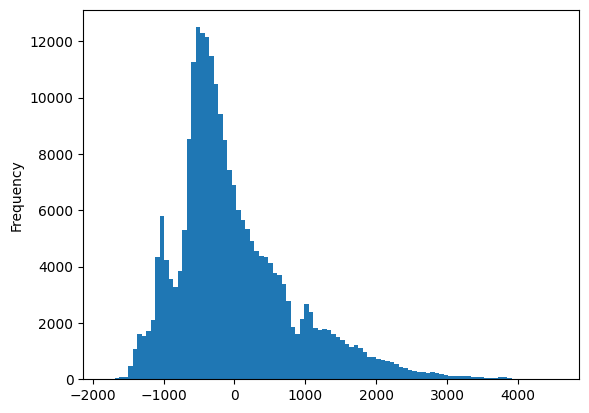

In [121]:
(y_test - y_pred).plot(kind = 'hist', bins = 100)

In [113]:
(y_test - y_pred).describe()

count    240000.000000
mean          1.191878
std         842.200258
min       -1816.536597
25%        -537.918550
50%        -210.811066
75%         398.647865
max        4546.373902
Name: Premium Amount, dtype: float64

In [123]:
stat, p = shapiro((y_test - y_pred))
print(f"Shapiro-Wilk Test Statistic: {stat}, p-value: {p}")

if p > 0.05:
    print("The data follows a normal distribution.")
else:
    print("The data does not follow a normal distribution.")

Shapiro-Wilk Test Statistic: 0.9188624232503837, p-value: 2.0086464630988104e-124
The data does not follow a normal distribution.


/home/container_user/.cache/pypoetry/virtualenvs/kaggle-DIsTaz0E-py3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 240000.
  res = hypotest_fun_out(*samples, **kwds)


skewed 되었으며 1000 근처에 뭔가있고 중위수가 살짝 낮음. 가설검정결과 정규분포 따르지 않음. 전처리단에서 타겟을 스케일링 해야할까?

## 3.3 feature importance

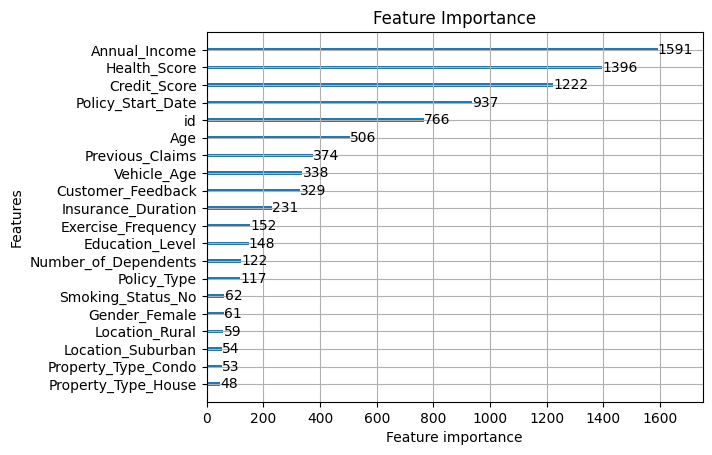

In [122]:
# Feature importance 시각화
lgb.plot_importance(model, max_num_features=20)
plt.title("Feature Importance")
plt.show()

- 우선 전처리부터

# 3. Conclusion

1. lgbm으로 학습이 무난히 진행되지만 목표점수에 많이 못미침
2. 가벼운 모델이라면 cross validation 필요해보임
3. 타겟에 대한 전처리 필요해 보임

# 4. Plan

- non-agile
    1. 코드 정리, 추상화, 모듈화
- agile
    1. 추가데데이터 분석
    2. 실험계획 리스트업